<a href="https://colab.research.google.com/github/AvichalTrivedi7/ANN-Deep-Learning-5th-Semester/blob/main/Lab4_Keras_MLP_Multiclass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 4 — Keras MLP for Multiclass Classification

Everything up to now has been binary — one output neuron answering yes/no. This one moves to **multiclass**: several possible answers, and the network has to pick exactly one.

Rather than running it on a stock dataset, I built it around an actual use case: a **smart climate controller** that reads room sensors and decides which appliance to fire — nothing, fan, AC, or heater. It's the same shape of problem as "should the light switch on," just with four possible actions instead of two, which is exactly what makes it multiclass.

**Pipeline:** sensor readings → scaling → hidden layers (ReLU) → output layer with 4 neurons (softmax) → probability for each action → pick the highest → fire that appliance.

## What actually changes from Practical 3

Structurally, almost nothing. The hidden layers are identical to Practical 3. Only the **output end** changes, and it changes in three linked ways:

| | Practical 3 (binary) | Practical 4 (multiclass) |
|---|---|---|
| Output neurons | 1 | 4 — one per class |
| Output activation | sigmoid | **softmax** |
| Loss | binary crossentropy | **categorical crossentropy** |
| Reading the answer | `output >= 0.5` | `argmax(outputs)` |

That's the whole difference. Everything I understood about hidden layers, ReLU and backprop from Practicals 1-3 carries over untouched — I'm only swapping the head of the network.

### In layman terms — why softmax and not just 4 sigmoids

This is the part worth actually getting, because "just use 4 sigmoid neurons" sounds like it should work.

If I put a sigmoid on each of the 4 outputs, each neuron independently squashes its own number into (0,1) — nothing stops all four from returning 0.9. The network would be saying "I'm 90% sure it's the fan, and also 90% sure it's the heater," which is meaningless when exactly one appliance should fire.

Softmax fixes this by looking at all 4 outputs **together**:

```
softmax(z_i) = e^(z_i) / sum over all j of e^(z_j)
```

Dividing each exponential by the sum of all of them forces the four outputs to add up to exactly 1. Now they're a genuine probability distribution over the classes — "70% fan, 25% AC, 4% nothing, 1% heater" — and raising one class's probability necessarily lowers the others. That competition between classes is the entire point, and it's what a bank of independent sigmoids can't give you.

The `e^x` also exaggerates gaps before normalising, so a clearly-leading class comes out sharply ahead rather than mushy — which is what makes the final `argmax` a confident decision instead of a coin flip.

### In layman terms — categorical crossentropy

Practical 2 used squared error `(a - target)^2`. For classification that's a poor fit, because it treats "predicted 0.6 when the answer was 1" as only mildly wrong.

Crossentropy instead looks only at the probability the network assigned to the **correct** class, and takes `-log` of it:

```
Loss = -log(probability assigned to the true class)
```

If the network gave the right class 0.99, loss is ~0.01 — barely penalised. If it gave the right class 0.01, loss is ~4.6 — punished heavily. The `-log` shape means confident-and-wrong is punished far more aggressively than unsure-and-wrong, which is exactly the behaviour you want from something that has to commit to one action.

Small practical note on the two Keras variants, since it's a common trip-up:
- `categorical_crossentropy` expects **one-hot** labels — `[0,0,1,0]`
- `sparse_categorical_crossentropy` expects **integer** labels — `2`

Same maths, different label format. I use the sparse version here so I can keep labels as plain integers.

## The use case — smart climate controller

**Setup:** a room with three sensors — temperature, humidity, and an occupancy sensor. The controller must pick one of four actions.

| Class | Action |
|:---:|---|
| 0 | Do nothing |
| 1 | Fan |
| 2 | AC |
| 3 | Heater |

**The rules the data is generated from** (the network never sees these — it only sees readings and the resulting action, and has to work the logic out for itself):

```
if room is EMPTY                      -> Do nothing      (no matter how hot or cold)
else:
    temp < 18                         -> Heater
    18 <= temp < 24                   -> Do nothing      (already comfortable)
    24 <= temp < 32  and humidity < 60 -> Fan            (warm but dry, air movement is enough)
    24 <= temp < 32  and humidity >= 60 -> AC            (warm and sticky, fan won't help)
    temp >= 32                        -> AC
```

I picked these rules deliberately rather than at random, because they contain three genuinely different kinds of logic:

1. **Plain thresholds** — `temp < 18 → Heater`. A straight line can do this. Practicals 1 and 2 could have handled it.
2. **A two-feature interaction** — Fan vs AC depends on temperature *and* humidity together. Neither feature alone is enough.
3. **A gate** — occupancy overrides everything. Same temperature and humidity give completely different answers depending on one other input. This is structurally the same problem as XOR from Practicals 1-3, which is precisely what a single neuron couldn't do.

So the dataset is built so that a linear model should partly succeed and partly fail, and I can point at exactly which parts. That's the experiment.

I also flip 5% of the labels at random, standing in for a sensor glitch or someone overriding the controller by hand. Real data is never perfectly clean, and it stops the problem being trivially solvable.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

CLASS_NAMES = ["Nothing", "Fan", "AC", "Heater"]

def rule_label(temp, humidity, occupied):
    """The ground-truth controller logic. The network never sees this function."""
    if occupied == 0:
        return 0                                  # nobody in the room -> do nothing
    if temp < 18:
        return 3                                  # Heater
    if temp < 24:
        return 0                                  # comfortable -> do nothing
    if temp < 32:
        return 1 if humidity < 60 else 2          # Fan if dry, AC if humid
    return 2                                      # too hot -> AC

def make_dataset(n, rng, occupied_prob=0.75, noise_frac=0.05):
    temp      = rng.uniform(10, 40, n)            # degrees C
    humidity  = rng.uniform(20, 90, n)            # percent
    occupancy = (rng.random(n) < occupied_prob).astype(int)

    labels = np.array([rule_label(temp[i], humidity[i], occupancy[i]) for i in range(n)])

    # 5% label noise - sensor glitch / manual override
    n_noise = int(noise_frac * n)
    idx = rng.choice(n, n_noise, replace=False)
    labels[idx] = rng.integers(0, 4, n_noise)

    X = np.column_stack([temp, humidity, occupancy])
    return X, labels

rng = np.random.default_rng(42)
X, y = make_dataset(3000, rng)

print("X shape:", X.shape, " (temperature, humidity, occupancy)")
print("y shape:", y.shape, " values:", np.unique(y))
print("\nFirst 5 rows:")
for i in range(5):
    print(f"  temp {X[i,0]:5.1f}C   humidity {X[i,1]:4.1f}%   occupied {int(X[i,2])}   ->  {CLASS_NAMES[y[i]]}")

I0000 00:00:1785162356.715507     544 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785162373.232652     544 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785162384.224982     544 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


X shape: (3000, 3)  (temperature, humidity, occupancy)
y shape: (3000,)  values: [0 1 2 3]

First 5 rows:
  temp  33.2C   humidity 78.0%   occupied 1   ->  AC
  temp  23.2C   humidity 61.6%   occupied 1   ->  Nothing
  temp  35.8C   humidity 37.1%   occupied 1   ->  AC
  temp  30.9C   humidity 72.2%   occupied 1   ->  AC
  temp  12.8C   humidity 25.9%   occupied 1   ->  Heater


In [ ]:
counts = np.bincount(y, minlength=4)
print("Class distribution:")
for k in range(4):
    print(f"  {k}  {CLASS_NAMES[k]:<8} {counts[k]:4d}  ({100*counts[k]/len(y):.1f}%)")

print(f"\nRandom guessing        : 25.0%")
print(f"Always predict '{CLASS_NAMES[counts.argmax()]}' : {100*counts.max()/len(y):.1f}%   <- the number to actually beat")
print(f"Noise ceiling          : ~{100*(0.95 + 0.05*0.25):.1f}%   (5% of labels are random, so perfect is impossible)")

Class distribution:
  0  Nothing  1163  (38.8%)
  1  Fan       365  (12.2%)
  2  AC        877  (29.2%)
  3  Heater    595  (19.8%)

Random guessing        : 25.0%
Always predict 'Nothing' : 38.8%   <- the number to actually beat
Noise ceiling          : ~96.2%   (5% of labels are random, so perfect is impossible)


#### Observation
The classes are imbalanced — "Nothing" is 38.8% of the data, "Fan" only 12.2%. That's realistic (a controller mostly does nothing) but it means **accuracy alone is a misleading score**. A model that blindly predicts "Nothing" every single time already scores 38.8% without learning anything at all, so that — not 25% — is the real bar to clear. It's also why the confusion matrix further down matters more than the headline accuracy number.

The 5% label noise puts a hard ceiling of roughly 96% on what any model can score. Anything reporting near-100% here would be memorising noise, not learning.

## Preprocessing

Two steps that didn't exist in Practicals 1-3, both worth understanding rather than copying:

**Train/test split.** Practicals 1-3 trained on 4 rows and tested on those same 4 rows — there was no way to tell learning apart from memorising. With 3000 samples that distinction finally matters, so 80% is used for training and 20% is held back and never seen during training.

**Feature scaling.** The three features live on completely different scales: temperature 10-40, humidity 20-90, occupancy 0-1. Gradient descent treats a "1 unit" change the same in every direction, so without scaling the humidity feature dominates the weight updates purely because its numbers are bigger, and occupancy — the single most important input — barely registers. `StandardScaler` re-centres each feature to mean 0, standard deviation 1, so all three start on equal footing.

Note the scaler is fitted on the **training set only**, then applied to the test set. Fitting it on all the data first would leak information about the test set into training.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler().fit(X_train)          # fit on TRAIN only
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} samples    Test: {X_test.shape[0]} samples")
print("\nBefore scaling - feature means:", X_train.mean(axis=0).round(2))
print("Before scaling - feature stds :", X_train.std(axis=0).round(2))
print("\nAfter scaling  - feature means:", X_train_s.mean(axis=0).round(2))
print("After scaling  - feature stds :", X_train_s.std(axis=0).round(2))

Train: 2400 samples    Test: 600 samples

Before scaling - feature means: [25.02 54.06  0.76]
Before scaling - feature stds : [ 8.69 20.03  0.43]

After scaling  - feature means: [ 0. -0.  0.]
After scaling  - feature stds : [1. 1. 1.]


## Baseline first — no hidden layer

Before building the MLP, the honest thing is to check what a model with **no hidden layer at all** manages. Input straight to a 4-neuron softmax output is exactly multinomial logistic regression — the direct multiclass version of the single neuron from Practical 2.

If this already scores well, the hidden layers aren't earning their place and I should say so. If it fails in a specific, explainable way, that failure is the argument for the MLP.

In [ ]:
def build_model(hidden_sizes, lr=0.01):
    tf.random.set_seed(42)
    layers = [tf.keras.layers.Input(shape=(3,))]
    for h in hidden_sizes:
        layers.append(tf.keras.layers.Dense(h, activation='relu'))
    layers.append(tf.keras.layers.Dense(4, activation='softmax'))   # 4 classes
    model = tf.keras.Sequential(layers)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

baseline = build_model([])           # no hidden layers
baseline.fit(X_train_s, y_train, epochs=100, batch_size=32, verbose=0)

base_acc = baseline.evaluate(X_test_s, y_test, verbose=0)[1]
base_pred = baseline.predict(X_test_s, verbose=0).argmax(axis=1)

print(f"Baseline (no hidden layer) test accuracy: {base_acc:.4f}\n")
print(classification_report(y_test, base_pred, target_names=CLASS_NAMES, digits=3, zero_division=0))

Baseline (no hidden layer) test accuracy: 0.9117

              precision    recall  f1-score   support

     Nothing      0.961     0.948     0.955       233
         Fan      0.808     0.575     0.672        73
          AC      0.856     0.949     0.900       175
      Heater      0.952     0.992     0.971       119

    accuracy                          0.912       600
   macro avg      0.894     0.866     0.874       600
weighted avg      0.910     0.912     0.908       600



#### Observation — where the linear model breaks, and why it's exactly where I expected
91.2% overall, which sounds fine until you read the per-class recall column:

- **Heater: 99.2%** — nearly perfect. It's a pure temperature threshold (`temp < 18`), which is a straight line, so a linear model handles it effortlessly.
- **Nothing: 94.8%**, **AC: 94.9%** — mostly threshold-driven too, both fine.
- **Fan: 57.5%** — it misses nearly half of them.

Fan is the *only* class that requires reasoning about two features at once (warm **and** dry). And looking at the confusion matrix below, the errors aren't scattered randomly — 23 of the 73 Fan cases get called AC specifically, which is precisely the humidity boundary the model cannot draw.

This is the same lesson as XOR from Practical 1, just showing up in a realistic problem instead of a toy truth table: thresholds on individual features are linear and easy, but a decision that depends on a **combination** of features needs a hidden layer.

In [ ]:
print("Confusion matrix - baseline (rows = actual, columns = predicted)")
print(f"{'':<10}" + "".join(f"{n:>10}" for n in CLASS_NAMES))
cm_base = confusion_matrix(y_test, base_pred)
for i, row in enumerate(cm_base):
    print(f"{CLASS_NAMES[i]:<10}" + "".join(f"{v:>10}" for v in row))

Confusion matrix - baseline (rows = actual, columns = predicted)
             Nothing       Fan        AC    Heater
Nothing          221         5         4         3
Fan                7        42        23         1
AC                 2         5       166         2
Heater             0         0         1       118


## The MLP

Two hidden layers, then the 4-neuron softmax output. 20% of the training data is held out again as a validation set so I can watch for overfitting while training, keeping the test set genuinely untouched until the end.

In [ ]:
mlp = build_model([16, 8])
mlp.summary()

history = mlp.fit(
    X_train_s, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

train_acc = mlp.evaluate(X_train_s, y_train, verbose=0)[1]
test_acc  = mlp.evaluate(X_test_s,  y_test,  verbose=0)[1]
mlp_pred  = mlp.predict(X_test_s, verbose=0).argmax(axis=1)

print(f"\nTrain accuracy: {train_acc:.4f}")
print(f"Test  accuracy: {test_acc:.4f}")
print(f"Baseline was  : {base_acc:.4f}\n")
print(classification_report(y_test, mlp_pred, target_names=CLASS_NAMES, digits=3, zero_division=0))

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236 (944.00 B)

 Trainable params: 236 (944.00 B)

 Non-trainable params: 0 (0.00 B)


Train accuracy: 0.9529
Test  accuracy: 0.9650
Baseline was  : 0.9117

              precision    recall  f1-score   support

     Nothing      0.978     0.966     0.972       233
         Fan      0.970     0.890     0.929        73
          AC      0.956     0.983     0.969       175
      Heater      0.951     0.983     0.967       119

    accuracy                          0.965       600
   macro avg      0.964     0.956     0.959       600
weighted avg      0.965     0.965     0.965       600



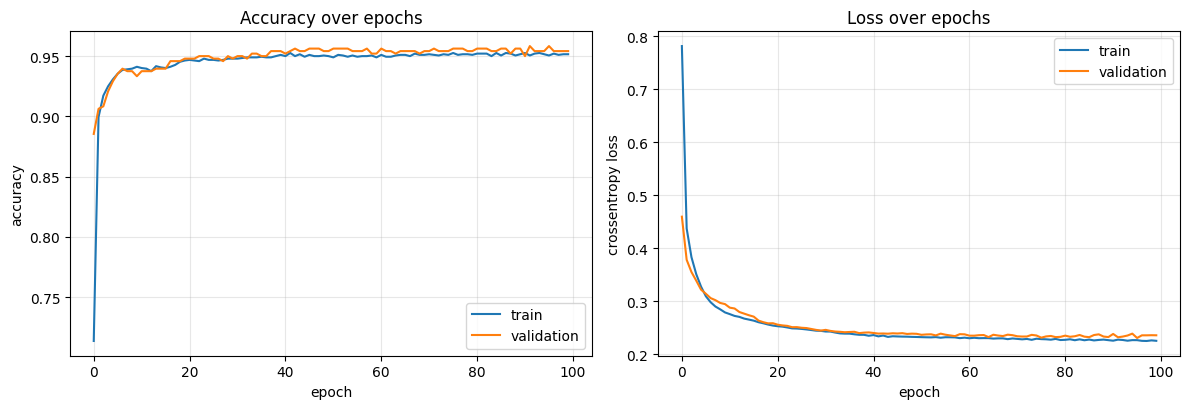

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='validation')
axes[0].set_title('Accuracy over epochs'); axes[0].set_xlabel('epoch'); axes[0].set_ylabel('accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='validation')
axes[1].set_title('Loss over epochs'); axes[1].set_xlabel('epoch'); axes[1].set_ylabel('crossentropy loss')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print("Confusion matrix - MLP (rows = actual, columns = predicted)")
print(f"{'':<10}" + "".join(f"{n:>10}" for n in CLASS_NAMES))
cm_mlp = confusion_matrix(y_test, mlp_pred)
for i, row in enumerate(cm_mlp):
    print(f"{CLASS_NAMES[i]:<10}" + "".join(f"{v:>10}" for v in row))

print("\nPer-class recall, baseline vs MLP:")
for k, name in enumerate(CLASS_NAMES):
    rb = cm_base[k, k] / cm_base[k].sum()
    rm = cm_mlp[k, k] / cm_mlp[k].sum()
    print(f"  {name:<8}  {100*rb:5.1f}%  ->  {100*rm:5.1f}%")

Confusion matrix - MLP (rows = actual, columns = predicted)
             Nothing       Fan        AC    Heater
Nothing          225         2         3         3
Fan                3        65         4         1
AC                 1         0       172         2
Heater             1         0         1       117

Per-class recall, baseline vs MLP:
  Nothing    94.8%  ->   96.6%
  Fan        57.5%  ->   89.0%
  AC         94.9%  ->   98.3%
  Heater     99.2%  ->   98.3%


#### Observation
Overall accuracy 91.2% → 96.5%. Framed as error rate that's **8.8% wrong → 3.5% wrong, so roughly 60% of the mistakes are gone**, and what's left is essentially the noise floor I built into the data.

The per-class breakdown is where the real story is:

- **Fan: 57.5% → 89.0%** — the big one, and Fan→AC confusions collapse from 23 down to 4.
- **Nothing: 94.8% → 96.6%**, **AC: 94.9% → 98.3%** — modest gains.
- **Heater: 99.2% → 98.3%** — actually a hair *worse*, by exactly one sample out of 119. It was already solved; there was nothing for the hidden layer to add.

So the hidden layer didn't lift everything uniformly. It bought almost exactly one thing — the class whose rule needs two features considered together — and left the already-linear classes where they were.

## What did the network actually learn?

Accuracy numbers are a summary. Since I know the true rules that generated the data, I can do something better than trust a score — I can sweep every temperature/humidity combination through both models and **draw the decision map each one learned**, then hold it against the real rules side by side.

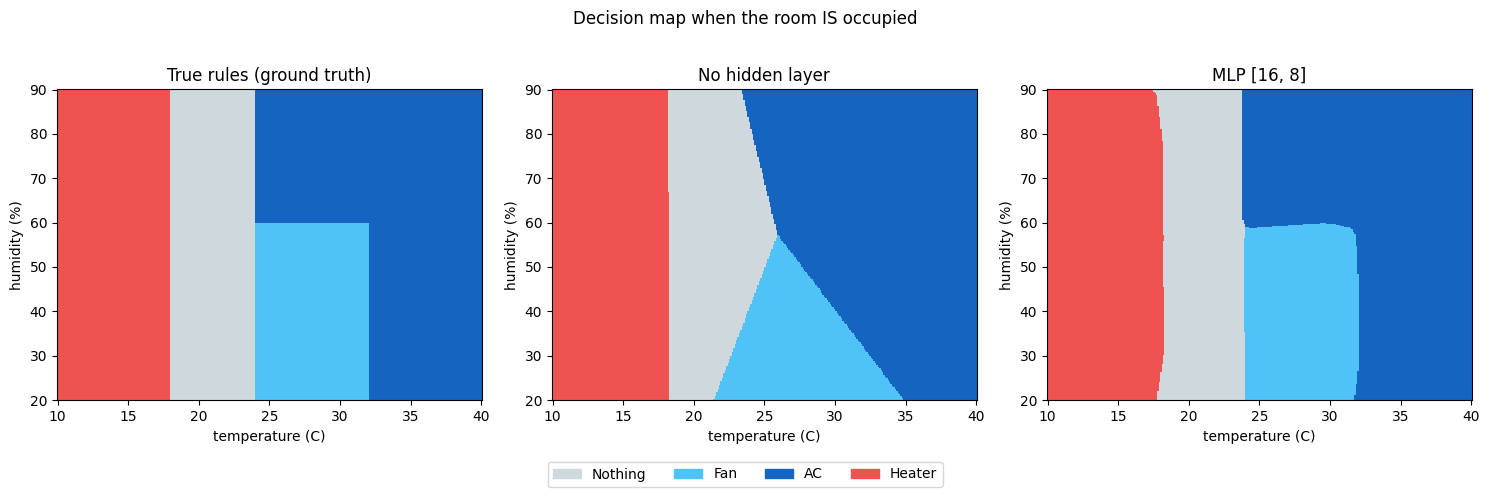

Agreement with the true rule map:
  no hidden layer : 90.58%
  MLP             : 98.57%

Region area each model assigns to every class (true value in brackets):
  Nothing  true  20.0%   linear  19.5%   MLP  19.1%
  Fan      true  15.2%   linear  11.9%   MLP  14.9%
  AC       true  38.1%   linear  41.0%   MLP  38.8%
  Heater   true  26.7%   linear  27.6%   MLP  27.2%


In [ ]:
cmap = ListedColormap(["#cfd8dc", "#4fc3f7", "#1565c0", "#ef5350"])
tt, hh = np.meshgrid(np.linspace(10, 40, 300), np.linspace(20, 90, 300))

def grid_input(occupied):
    return np.column_stack([tt.ravel(), hh.ravel(), np.full(tt.size, occupied)])

true_map = np.array([rule_label(t, h, 1) for t, h in zip(tt.ravel(), hh.ravel())]).reshape(tt.shape)
base_map = baseline.predict(scaler.transform(grid_input(1)), verbose=0).argmax(1).reshape(tt.shape)
mlp_map  = mlp.predict(scaler.transform(grid_input(1)), verbose=0).argmax(1).reshape(tt.shape)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, grid, title in zip(axes, [true_map, base_map, mlp_map],
                           ["True rules (ground truth)", "No hidden layer", "MLP [16, 8]"]):
    ax.pcolormesh(tt, hh, grid, cmap=cmap, vmin=0, vmax=3, shading='auto')
    ax.set_title(title); ax.set_xlabel("temperature (C)"); ax.set_ylabel("humidity (%)")

handles = [plt.Rectangle((0,0),1,1, color=cmap(i)) for i in range(4)]
fig.legend(handles, CLASS_NAMES, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.08))
plt.suptitle("Decision map when the room IS occupied", y=1.02)
plt.tight_layout()
plt.show()

print("Agreement with the true rule map:")
print(f"  no hidden layer : {100*(base_map == true_map).mean():.2f}%")
print(f"  MLP             : {100*(mlp_map  == true_map).mean():.2f}%")

print("\nRegion area each model assigns to every class (true value in brackets):")
for k, name in enumerate(CLASS_NAMES):
    print(f"  {name:<8} true {100*(true_map==k).mean():5.1f}%   "
          f"linear {100*(base_map==k).mean():5.1f}%   MLP {100*(mlp_map==k).mean():5.1f}%")

#### Observation
The MLP reconstructs **98.6%** of the true rule map against the linear model's 90.6%, and the region areas pin down exactly where the linear model loses it:

| | true area | linear | MLP |
|---|:---:|:---:|:---:|
| Fan | 15.2% | **11.9%** | 14.9% |
| AC | 38.1% | **41.0%** | 38.8% |

The linear model under-draws Fan by about a fifth of its true area and hands that territory to AC. It cannot cut the horizontal humidity boundary at 60% that separates the two, so it approximates it with a slanted line and loses the corner. The MLP lands within a few tenths of a percent on every region.

Look at the shape of the MLP's map and you'll see visible corners in it. Those corners are ReLU units switching on and off — the identical mechanism from Practical 3 that bent a boundary around XOR, doing the same job here on a problem that looks nothing like a truth table.

In [ ]:
empty_map = mlp.predict(scaler.transform(grid_input(0)), verbose=0).argmax(1).reshape(tt.shape)

print("Room EMPTY - what does the MLP do across every temp/humidity combination?")
print("  classes predicted:", [CLASS_NAMES[k] for k in np.unique(empty_map)])
print(f"  fraction predicted 'Nothing': {100*(empty_map == 0).mean():.1f}%")

Room EMPTY - what does the MLP do across every temp/humidity combination?
  classes predicted: ['Nothing']
  fraction predicted 'Nothing': 100.0%


#### Observation — the gate
Across all 90,000 temperature/humidity combinations, with the room empty, the network predicts "do nothing" **100% of the time**. It learned that occupancy overrides every other reading, from nothing but examples — nobody encoded that rule anywhere.

This is the part I find genuinely satisfying. It's the same structure as XOR: one input completely changes the meaning of the others. A 40°C reading means "fire the AC" or "do nothing" depending entirely on a separate binary input, and the network sorted that out on its own.

## The actual firing decision

The end product isn't an accuracy score, it's a controller that has to commit to one action. Here are hand-picked scenarios pushed through the trained network, showing the full softmax distribution and the action it would fire.

The last two are the interesting pair — **identical temperature and humidity, only occupancy differs**.

In [ ]:
scenarios = [
    ("Cold winter morning, someone in the room",  12.0, 45.0, 1),
    ("Pleasant evening, someone in the room",     21.5, 50.0, 1),
    ("Warm and dry afternoon, occupied",          27.0, 35.0, 1),
    ("Warm and humid afternoon, occupied",        27.0, 75.0, 1),
    ("Blazing hot, occupied",                     36.0, 65.0, 1),
    ("Blazing hot, room is EMPTY",                36.0, 65.0, 0),
]

for desc, t, h, occ in scenarios:
    probs = mlp.predict(scaler.transform(np.array([[t, h, occ]])), verbose=0)[0]
    action = CLASS_NAMES[probs.argmax()]
    bars = "   ".join(f"{CLASS_NAMES[i]}: {probs[i]*100:5.1f}%" for i in range(4))
    print(f"{desc}")
    print(f"  {t}C, {h}% humidity, occupied={occ}")
    print(f"  {bars}")
    print(f"  >>> FIRE: {action}\n")

Cold winter morning, someone in the room
  12.0C, 45.0% humidity, occupied=1
  Nothing:   1.8%   Fan:   6.8%   AC:   2.8%   Heater:  88.6%
  >>> FIRE: Heater



Pleasant evening, someone in the room
  21.5C, 50.0% humidity, occupied=1
  Nothing:  97.5%   Fan:   1.7%   AC:   0.2%   Heater:   0.6%
  >>> FIRE: Nothing



Warm and dry afternoon, occupied
  27.0C, 35.0% humidity, occupied=1
  Nothing:   2.5%   Fan:  96.8%   AC:   0.5%   Heater:   0.3%
  >>> FIRE: Fan



Warm and humid afternoon, occupied
  27.0C, 75.0% humidity, occupied=1
  Nothing:   0.6%   Fan:   0.8%   AC:  98.0%   Heater:   0.6%
  >>> FIRE: AC



Blazing hot, occupied
  36.0C, 65.0% humidity, occupied=1
  Nothing:   0.2%   Fan:   0.8%   AC:  98.0%   Heater:   1.0%
  >>> FIRE: AC



Blazing hot, room is EMPTY
  36.0C, 65.0% humidity, occupied=0
  Nothing:  99.7%   Fan:   0.2%   AC:   0.1%   Heater:   0.1%
  >>> FIRE: Nothing



#### Observation
Every scenario fires the correct appliance, and the softmax probabilities show the network is confident rather than scraping past a threshold.

The final two rows are the whole point of the use case. Same 36°C, same 65% humidity — the only thing that changed is whether anyone is in the room, and the decision flips completely from AC to doing nothing. That's the "smart" part of a smart controller, and it's the piece that needs a hidden layer to work at all.

## Sanity check on real data — handwritten digits

The climate dataset is synthetic, which is what let me compare against known ground-truth rules. Fair question in return: does the same code do anything on real measured data? Same architecture pattern, real handwritten digit images from scikit-learn, and 10 classes instead of 4.

data shape: (1797, 64)  (1797 images, 8x8 pixels flattened to 64 features)
classes: [0 1 2 3 4 5 6 7 8 9]


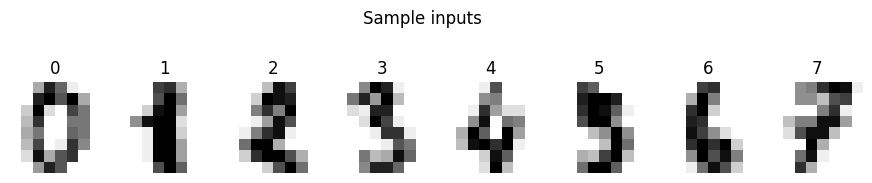

In [ ]:
from sklearn.datasets import load_digits

digits = load_digits()
print("data shape:", digits.data.shape, " (1797 images, 8x8 pixels flattened to 64 features)")
print("classes:", np.unique(digits.target))

fig, axes = plt.subplots(1, 8, figsize=(11, 1.8))
for ax, img, lab in zip(axes, digits.images, digits.target):
    ax.imshow(img, cmap='gray_r'); ax.set_title(str(lab)); ax.axis('off')
plt.suptitle("Sample inputs", y=1.15)
plt.show()

In [ ]:
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=42, stratify=digits.target
)
scaler_d = StandardScaler().fit(Xd_tr)
Xd_tr_s, Xd_te_s = scaler_d.transform(Xd_tr), scaler_d.transform(Xd_te)

tf.random.set_seed(42)
digit_mlp = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(64,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax'),      # 10 classes now
])
digit_mlp.compile(optimizer=tf.keras.optimizers.Adam(0.001),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
digit_mlp.fit(Xd_tr_s, yd_tr, epochs=60, batch_size=32, validation_split=0.2, verbose=0)

print(f"Train accuracy: {digit_mlp.evaluate(Xd_tr_s, yd_tr, verbose=0)[1]:.4f}")
print(f"Test  accuracy: {digit_mlp.evaluate(Xd_te_s, yd_te, verbose=0)[1]:.4f}")

Train accuracy: 0.9910
Test  accuracy: 0.9694


#### Observation
96.9% on the held-out test set, on real measured data, with 10 classes. The only lines that changed from the climate model are the input width (64 instead of 3) and the output width (10 instead of 4) — softmax, crossentropy, scaling and the overall shape all carried over untouched. Train accuracy sits higher at 99.1%, a ~2 point gap, which is the mild overfitting you'd expect from a network this size on under 1500 training images.

## Two experiments behind the choices above

Both of these are claims I'd otherwise be making on faith, so they're run here rather than asserted.

### Experiment 1 — does feature scaling actually matter?

Identical architecture and training settings, the only change being raw features instead of scaled ones. Running it across several random seeds rather than once, because a single run can't tell a real effect apart from a lucky initialisation.

In [ ]:
def train_eval(X_tr_in, X_te_in, seed, hidden=(16, 8)):
    tf.random.set_seed(seed)
    layers = [tf.keras.layers.Input(shape=(3,))]
    for h in hidden:
        layers.append(tf.keras.layers.Dense(h, activation='relu'))
    layers.append(tf.keras.layers.Dense(4, activation='softmax'))
    m = tf.keras.Sequential(layers)
    m.compile(optimizer=tf.keras.optimizers.Adam(0.01),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    m.fit(X_tr_in, y_train, epochs=100, batch_size=32, verbose=0)
    acc = m.evaluate(X_te_in, y_test, verbose=0)[1]
    n_classes_used = len(np.unique(m.predict(X_te_in, verbose=0).argmax(axis=1)))
    return acc, n_classes_used

seeds = [0, 1, 7, 42, 123]
scaled_accs, raw_accs = [], []

print(f"{'seed':<8}{'SCALED':>10}{'classes':>10}{'RAW':>10}{'classes':>10}")
print("-" * 48)
for s in seeds:
    sa, sc_n = train_eval(X_train_s, X_test_s, s)
    ra, rc_n = train_eval(X_train,   X_test,   s)
    scaled_accs.append(sa); raw_accs.append(ra)
    print(f"{s:<8}{sa:>10.4f}{sc_n:>10}{ra:>10.4f}{rc_n:>10}")

print(f"\nSCALED  mean {np.mean(scaled_accs):.4f}   worst {min(scaled_accs):.4f}   spread {max(scaled_accs)-min(scaled_accs):.4f}")
print(f"RAW     mean {np.mean(raw_accs):.4f}   worst {min(raw_accs):.4f}   spread {max(raw_accs)-min(raw_accs):.4f}")

seed        SCALED   classes       RAW   classes
------------------------------------------------


0           0.9617         4    0.8350         4


1           0.9583         4    0.9450         4


7           0.9583         4    0.9433         4


42          0.9650         4    0.9317         4


123         0.9583         4    0.3883         1

SCALED  mean 0.9603   worst 0.9583   spread 0.0067
RAW     mean 0.8087   worst 0.3883   spread 0.5567


#### Observation
This is the experiment that changed my mind about something, so it's worth reading the numbers carefully rather than the summary.

```
SCALED  mean 0.9603   worst 0.9583   spread 0.0067
RAW     mean 0.8087   worst 0.3883   spread 0.5567
```

Scaled training is boringly consistent — five seeds, all within 0.7 of a percentage point of each other. Raw training is all over the place: 94.5% on one seed, 83.5% on another, and on seed 123 it **collapsed to predicting a single class for every input**, scoring 38.8%, which is precisely the "always say Nothing" rate from the class distribution.

The important nuance is that raw features don't reliably fail. Four of the five seeds trained to something usable. What scaling actually buys is **reliability** — without it, whether the model works at all depends on the luck of the initialisation. Occupancy is the most important feature in this problem but only ever takes the value 0 or 1, sitting next to a temperature feature spanning 10-40; if the initial weights happen to start it off small, its gradient contribution is swamped and the model can settle into ignoring it entirely.

I originally ran this on one seed, saw the 38.8% collapse, and was about to write it up as "scaling is mandatory or the model breaks." Running it across five seeds shows that's overclaiming — the correct statement is that unscaled training is a coin flip, and a 55 point spread is reason enough never to skip it.

### Experiment 2 — how much network does this problem actually need?

Averaged over 3 seeds each, for the same reason. Note these runs train on the full training set with no validation split, so the `[16,8]` number here differs very slightly from the main model above, which held back 20% for validation.

In [ ]:
print(f"{'architecture':<18}{'train':>10}{'test':>10}{'gap':>9}")
print("-" * 47)
for hidden in ((), (8,), (16,), (16, 8), (32, 16)):
    trs, tes = [], []
    for s in (0, 42, 123):
        tf.random.set_seed(s)
        layers = [tf.keras.layers.Input(shape=(3,))]
        for h in hidden:
            layers.append(tf.keras.layers.Dense(h, activation='relu'))
        layers.append(tf.keras.layers.Dense(4, activation='softmax'))
        m = tf.keras.Sequential(layers)
        m.compile(optimizer=tf.keras.optimizers.Adam(0.01),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        m.fit(X_train_s, y_train, epochs=100, batch_size=32, verbose=0)
        trs.append(m.evaluate(X_train_s, y_train, verbose=0)[1])
        tes.append(m.evaluate(X_test_s,  y_test,  verbose=0)[1])
    label = "none (linear)" if not hidden else str(list(hidden))
    print(f"{label:<18}{np.mean(trs):>10.4f}{np.mean(tes):>10.4f}{np.mean(trs)-np.mean(tes):>9.4f}")

architecture           train      test      gap
-----------------------------------------------


none (linear)         0.8988    0.9189  -0.0201


[8]                   0.9443    0.9556  -0.0112


[16]                  0.9486    0.9594  -0.0108


[16, 8]               0.9554    0.9656  -0.0101


[32, 16]              0.9533    0.9622  -0.0089


#### Observation
Every architecture with a hidden layer clears the linear baseline by 3.5-4.5 points, and they then all bunch together, because the 5% label noise caps how high anything can go.

`[16,8]` posts the best test accuracy at 96.6%, and `[32,16]` — twice the size — does slightly *worse* at 96.2%. Doubling capacity bought nothing, which is the same conclusion as the 2-vs-4 hidden-neuron test in Practical 3, reached on a completely different problem: once the network can represent the function, extra capacity stops helping.

`[16,8]` is therefore the pick — the smallest architecture that reaches the ceiling.

(The gap column is negative throughout, i.e. test scoring above train. That's the label-noise artifact explained in the notes below, not a sign of underfitting.)

### Personal notes

**The scaling experiment taught me more than the model did.** My first run of it used a single seed, the unscaled model collapsed to 38.8%, and I had already written down "scaling is mandatory, without it the model breaks." Re-running across five seeds showed that was wrong — four of the five trained fine, reaching 83-94%. Only one collapsed. The honest finding isn't "it breaks," it's "it's a coin flip": a 55 point spread across seeds versus 0.7 points when scaled. Same practical advice at the end (always scale), but for a different and more accurate reason, and I'd rather be able to defend the real one. Worth remembering that a single run is an anecdote, not a result.

**Picking the architecture.** `[8]`, `[16]`, `[16,8]` and `[32,16]` all land within a point of each other once past the linear baseline, and `[32,16]` is actually marginally worse than `[16,8]` despite being twice the size. Consistent with Practical 3's hidden-size finding. I went with `[16,8]` as the smallest one that reaches the noise ceiling.

**The result I'd point at if asked what this practical taught me** is the per-class recall comparison, not the headline accuracy. Overall 91.2% → 96.5% is easy to dismiss as a small gain. But Heater sat at ~99% under *both* models (it even dropped by one sample), while Fan went 57.5% → 89.0%. That split is the actual finding: the hidden layer didn't improve the model evenly, it fixed one specific class — the only one whose rule depends on two features interacting — and left everything else alone. That maps exactly onto Practicals 1-3, where a single neuron handled AND and OR but couldn't touch XOR. Same limitation, same fix, wearing different clothes.

**One honest wrinkle:** test accuracy (96.5%) came out slightly *above* training accuracy (95.3%), which looks backwards, and it shows up in the architecture table too. It's a consequence of the 5% random label noise landing unevenly across the split — the training set caught slightly more corrupted labels than the test set, and corrupted labels are impossible to fit by definition, so they permanently drag training accuracy down. Not a bug, but I'd rather know why it happened than hope nobody asks.

#### Summary
- Multiclass changes only the head of the network: N output neurons, softmax instead of sigmoid, crossentropy instead of squared error, `argmax` instead of a 0.5 threshold. The hidden layers from Practical 3 carry over untouched.
- **Softmax** is what makes the outputs a genuine probability distribution — they're forced to sum to 1, so raising one class necessarily lowers the others. Four independent sigmoids can't do this and would happily claim 90% confidence in two different appliances at once.
- **Crossentropy** punishes confident-and-wrong far harder than unsure-and-wrong, which is the right incentive for something that must commit to a single action.
- On the climate controller: linear baseline 91.2%, MLP 96.5% — but the useful reading is per class. Heater (a plain temperature threshold) was already at 99% and didn't move; Fan (needs temperature **and** humidity together) went 57.5% → 89.0%. The hidden layer fixed exactly the non-linear part.
- Sweeping the full input space, the MLP reproduces **98.6%** of the ground-truth rule map versus the linear model's 90.6%, under-drawing the Fan region being the linear model's specific failure.
- The network learned the occupancy gate perfectly — empty room predicts "do nothing" across 100% of temperature/humidity space — without ever being shown the rule. Structurally the same problem as XOR from Practicals 1-3.
- Feature scaling is about reliability, not just accuracy: unscaled training ranged from 38.8% (total collapse onto the majority class) to 94.5% depending purely on the random seed, a 55 point spread, versus 0.7 points when scaled.
- The same code pattern transfers straight to real data — 96.9% on 10-class handwritten digits with only the input and output widths changed.